# ♻️ Reusable Linear Regression Project Template (Lending / Transactional Data Edition)
A generic, parameterized notebook you can point at **any new dataset** with a continuous
outcome and a mix of numeric/categorical predictors. Fill in the **CONFIG** cell, then
run everything below top-to-bottom.

This version adds two things the PSID template didn't need: a **de-duplication** step
and support for **structural-zero ratio columns** (common in lending/transactional data,
e.g. DTI, loan-to-value, utilization rate).

Demonstrated here against `bank_loans_sim.csv`, but every function below is
dataset-agnostic.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. CONFIG — the only cell you *must* edit for a new project

In [2]:
CONFIG = {
    "csv_path": "bank_loans_sim.csv",
    "index_col": None,

    # Columns to ignore when checking for exact duplicate rows (surrogate keys, etc.)
    "dedup_ignore_cols": ["row_id", "loan_id"],

    # Sentinel/missing codes to replace with NaN, per column
    "sentinel_codes": {
        "credit_score": [0],
        "annual_income": [-1],
        "employment_years": [99],
        "interest_rate": [999],
    },

    # Structural-zero ratio columns: a ratio column that should be nulled out whenever
    # its denominator-source column is missing (e.g. DTI needs income; LTV needs
    # appraised value). Format: {ratio_col: denominator_source_col}
    "structural_zero_ratios": {
        "dti": "annual_income",
    },

    # Columns that must be non-null after all cleaning
    "required_non_null": ["credit_score", "annual_income", "employment_years",
                           "dti", "interest_rate"],

    # The outcome variable, and whether to log-transform it. Leave False for bounded
    # rates/percentages; consider True for unbounded, right-skewed dollar/count outcomes.
    "outcome": "interest_rate",
    "log_transform_outcome": False,

    # Predictor columns to check for skew and optionally log-transform.
    # Format: {new_column: source_column}
    "log_transform_predictors": {
        "log_loan_amount": "loan_amount",
        "log_annual_income": "annual_income",
    },

    # Column used for IQR-based outlier trimming (usually the outcome, or a key
    # engineered ratio predictor)
    "outlier_trim_column": "dti",

    # Formula predictors for the simple model (must be a single numeric column)
    "simple_predictor": "credit_score",

    # Formula RHS for the multiple model
    "multi_formula_rhs": ("credit_score + dti + log_loan_amount + log_annual_income "
                           "+ employment_years + delinq_2yr + C(term_months) "
                           "+ C(loan_purpose) + C(verified_income) + C(home_ownership)"),

    "test_size": 0.2,
    "random_state": 42,
    "iqr_k": 1.5,
}


## 3. Reusable Functions

In [3]:
def load_data(config):
    return pd.read_csv(config["csv_path"], index_col=config.get("index_col"))


def drop_duplicates(df, config):
    """Drop exact duplicate rows, ignoring surrogate-key columns."""
    ignore = config.get("dedup_ignore_cols", [])
    subset = [c for c in df.columns if c not in ignore]
    before = len(df)
    df = df.drop_duplicates(subset=subset).copy()
    print(f"  de-dup: {before} -> {len(df)} rows")
    return df


def clean_sentinels(df, config):
    """Replace known sentinel/missing codes with NaN, column by column."""
    df = df.copy()
    for col, codes in config.get("sentinel_codes", {}).items():
        n_bad = df[col].isin(codes).sum()
        if n_bad:
            print(f"  {col}: replacing {n_bad} sentinel-coded rows with NaN")
        df[col] = df[col].replace(codes, np.nan)
    return df


def resolve_structural_zero_ratios(df, config):
    """Null out a ratio column wherever its denominator-source column is missing
    AND the ratio is exactly zero -- the classic 'system defaulted to 0' pattern."""
    df = df.copy()
    for ratio_col, source_col in config.get("structural_zero_ratios", {}).items():
        mask = df[source_col].isna() & (df[ratio_col] == 0)
        print(f"  {ratio_col}: nulling {mask.sum()} structural-zero rows "
              f"(driven by missing {source_col})")
        df.loc[mask, ratio_col] = np.nan
    return df


def apply_required_filter(df, config):
    """Drop rows missing any required field."""
    required = config.get("required_non_null", [])
    before = len(df)
    df = df.dropna(subset=required).copy()
    print(f"  drop rows missing {required}: {before} -> {len(df)} rows")
    return df


def add_log_predictors(df, config):
    """Create log-transformed versions of configured predictor columns."""
    df = df.copy()
    for new_col, source_col in config.get("log_transform_predictors", {}).items():
        df[new_col] = np.log(df[source_col])
        print(f"  {new_col} = log({source_col})  "
              f"(skew before: {df[source_col].skew():.2f}, after: {df[new_col].skew():.2f})")
    return df


def add_outcome(df, config):
    """Add a (possibly log-transformed) outcome column called 'model_outcome'."""
    df = df.copy()
    outcome = config["outcome"]
    if config.get("log_transform_outcome"):
        df["model_outcome"] = np.log(df[outcome])
        print(f"  model_outcome = log({outcome})")
    else:
        df["model_outcome"] = df[outcome]
    return df


def trim_outliers_iqr(df, column, k=1.5):
    """Drop rows outside the IQR fences of `column`."""
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    before = len(df)
    trimmed = df[(df[column] >= lo) & (df[column] <= hi)]
    print(f"  IQR trim on {column} (k={k}): bounds [{lo:.2f},{hi:.2f}], "
          f"{before} -> {len(trimmed)} rows")
    return trimmed


def eda_report(df, numeric_cols, outcome_col):
    """Print correlations and show scatterplots of each numeric predictor vs outcome."""
    for col in numeric_cols:
        r, p = stats.pearsonr(df[col], df[outcome_col])
        print(f"{col:>20s} vs {outcome_col}: r = {r:6.3f}, p = {p:.2e}")
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        sns.scatterplot(data=df, x=col, y=outcome_col, alpha=0.4, ax=ax)
    plt.tight_layout()
    plt.show()


def fit_ols(df, formula):
    return smf.ols(formula, data=df).fit()


def fit_summary_table(model, log_outcome=False):
    table = model.params.to_frame("coefficient")
    if log_outcome:
        table["pct_effect"] = (np.exp(table["coefficient"]) - 1) * 100
    table["p_value"] = model.pvalues
    table["ci_low"], table["ci_high"] = model.conf_int()[0], model.conf_int()[1]
    return table.round(4)


def residual_diagnostics(model, figsize=(11, 4)):
    fitted, resid = model.fittedvalues, model.resid
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].scatter(fitted, resid, alpha=0.4)
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set(xlabel="Fitted values", ylabel="Residuals", title="Residuals vs Fitted")
    sm.qqplot(resid, line="45", fit=True, ax=axes[1])
    axes[1].set_title("Normal Q-Q")
    plt.tight_layout()
    plt.show()


def evaluate_on_test(model, test_df, outcome_col="model_outcome"):
    preds = model.predict(test_df)
    r2 = r2_score(test_df[outcome_col], preds)
    rmse = np.sqrt(mean_squared_error(test_df[outcome_col], preds))
    baseline_pred = np.full(len(test_df), model.model.endog.mean())
    baseline_rmse = np.sqrt(mean_squared_error(test_df[outcome_col], baseline_pred))
    return {
        "test_r2": r2, "test_rmse": rmse, "baseline_rmse": baseline_rmse,
        "improvement_vs_baseline_pct": (1 - rmse / baseline_rmse) * 100,
    }


def compute_vif(df, columns):
    X = pd.get_dummies(df[columns], drop_first=True)
    X = sm.add_constant(X.astype(float))
    return pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }).query("variable != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True)


def compare_models(model_a, model_b, label_a="model_a", label_b="model_b"):
    print(f"{label_a}: R2={model_a.rsquared:.4f}  Adj.R2={model_a.rsquared_adj:.4f}")
    print(f"{label_b}: R2={model_b.rsquared:.4f}  Adj.R2={model_b.rsquared_adj:.4f}")
    return anova_lm(model_a, model_b)


print("Helper functions loaded:")
for fn in [load_data, drop_duplicates, clean_sentinels, resolve_structural_zero_ratios,
           apply_required_filter, add_log_predictors, add_outcome, trim_outliers_iqr,
           eda_report, fit_ols, fit_summary_table, residual_diagnostics,
           evaluate_on_test, compute_vif, compare_models]:
    print(" -", fn.__name__)


Helper functions loaded:
 - load_data
 - drop_duplicates
 - clean_sentinels
 - resolve_structural_zero_ratios
 - apply_required_filter
 - add_log_predictors
 - add_outcome
 - trim_outliers_iqr
 - eda_report
 - fit_ols
 - fit_summary_table
 - residual_diagnostics
 - evaluate_on_test
 - compute_vif
 - compare_models


## 4. Run the Pipeline

In [4]:
print("Loading data...")
raw = load_data(CONFIG)
print(raw.shape)


Loading data...
(5214, 14)


In [5]:
print("Removing duplicates...")
df = drop_duplicates(raw, CONFIG)


Removing duplicates...
  de-dup: 5214 -> 5200 rows


In [6]:
print("Cleaning sentinel codes...")
df = clean_sentinels(df, CONFIG)


Cleaning sentinel codes...
  credit_score: replacing 156 sentinel-coded rows with NaN
  annual_income: replacing 312 sentinel-coded rows with NaN
  employment_years: replacing 208 sentinel-coded rows with NaN
  interest_rate: replacing 5 sentinel-coded rows with NaN


In [7]:
print("Resolving structural-zero ratio columns...")
df = resolve_structural_zero_ratios(df, CONFIG)


Resolving structural-zero ratio columns...
  dti: nulling 312 structural-zero rows (driven by missing annual_income)


In [8]:
print("Filtering to required-complete rows...")
df = apply_required_filter(df, CONFIG)


Filtering to required-complete rows...
  drop rows missing ['credit_score', 'annual_income', 'employment_years', 'dti', 'interest_rate']: 5200 -> 4546 rows


In [9]:
print("Adding log-transformed predictors...")
df = add_log_predictors(df, CONFIG)
print("Adding model outcome...")
df = add_outcome(df, CONFIG)


Adding log-transformed predictors...
  log_loan_amount = log(loan_amount)  (skew before: 1.51, after: -0.00)
  log_annual_income = log(annual_income)  (skew before: 1.62, after: 0.02)
Adding model outcome...


        credit_score vs model_outcome: r = -0.542, p = 0.00e+00
                 dti vs model_outcome: r =  0.284, p = 7.65e-85


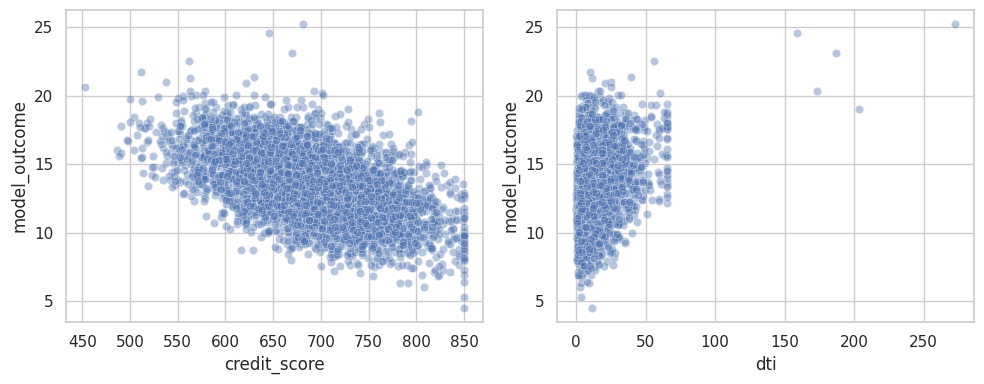

In [10]:
eda_report(df, numeric_cols=[CONFIG["simple_predictor"], "dti"], outcome_col="model_outcome")


In [11]:
clean_df = trim_outliers_iqr(df, CONFIG["outlier_trim_column"], k=CONFIG["iqr_k"])


  IQR trim on dti (k=1.5): bounds [-11.85,32.55], 4546 -> 4274 rows


In [12]:
train, test = train_test_split(
    clean_df, test_size=CONFIG["test_size"], random_state=CONFIG["random_state"]
)
print(f"Train: {len(train)}   Test: {len(test)}")


Train: 3419   Test: 855


In [13]:
simple_formula = f"model_outcome ~ {CONFIG['simple_predictor']}"
model_simple = fit_ols(train, simple_formula)
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:          model_outcome   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     1509.
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          8.82e-274
Time:                        20:00:58   Log-Likelihood:                -7228.7
No. Observations:                3419   AIC:                         1.446e+04
Df Residuals:                    3417   BIC:                         1.447e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       27.5387      0.367     75.082   

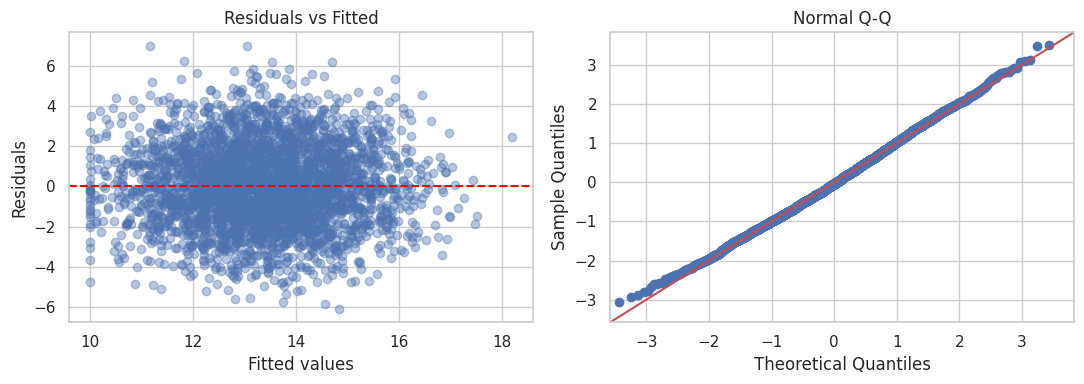

In [14]:
residual_diagnostics(model_simple)


In [15]:
multi_formula = f"model_outcome ~ {CONFIG['multi_formula_rhs']}"
model_multi = fit_ols(train, multi_formula)
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:          model_outcome   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     349.3
Date:                Sat, 22 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:00:58   Log-Likelihood:                -6064.1
No. Observations:                3419   AIC:                         1.217e+04
Df Residuals:                    3400   BIC:                         1.228e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

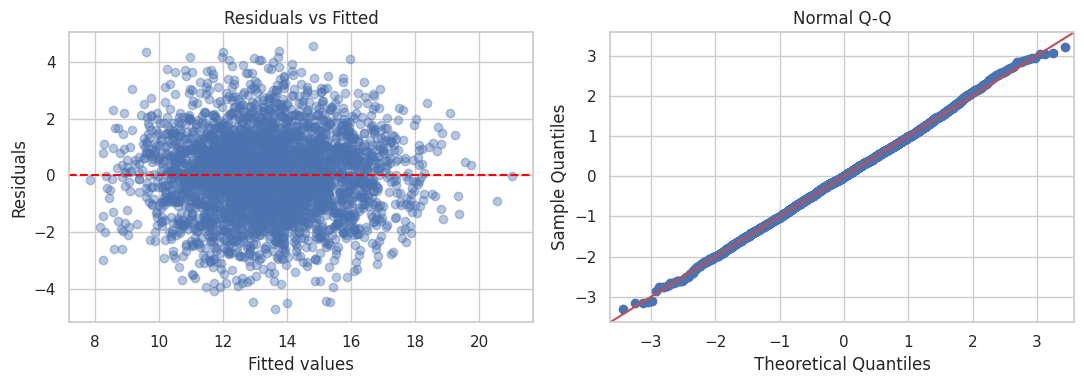

In [16]:
residual_diagnostics(model_multi)


In [17]:
compare_models(model_simple, model_multi, "simple", "multi")


simple: R2=0.3064  Adj.R2=0.3062
multi: R2=0.6490  Adj.R2=0.6472


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,3417.0,13736.281972,0.0,NaN,NaN,NaN
1,3400.0,6950.274262,17.0,6786.00771,195.273092,0.0


In [18]:
fit_summary_table(model_multi, log_outcome=CONFIG["log_transform_outcome"])


,coefficient,p_value,ci_low,ci_high
Intercept,26.4348,0.0000,24.7879,28.0816
C(term_months)[T.60],2.1343,0.0000,2.0324,2.2362
C(loan_purpose)[T.debt_consolidation],-0.3605,0.0000,-0.4893,-0.2316
C(loan_purpose)[T.home_improvement],-1.0231,0.0000,-1.1953,-0.8510
C(loan_purpose)[T.major_purchase],-0.7576,0.0000,-0.9532,-0.5620
C(loan_purpose)[T.medical],0.1398,0.2601,-0.1036,0.3832
C(loan_purpose)[T.other],-0.0314,0.7555,-0.2292,0.1663
C(loan_purpose)[T.small_business],1.0052,0.0000,0.7996,1.2109
C(verified_income)[T.Source Verified],-0.5342,0.0000,-0.6576,-0.4108
C(verified_income)[T.Verified],-0.7696,0.0000,-0.8966,-0.6427


In [19]:
print("Simple model test performance:", evaluate_on_test(model_simple, test))
print("Multi model test performance:  ", evaluate_on_test(model_multi, test))


Simple model test performance: {'test_r2': 0.3296208280199785, 'test_rmse': np.float64(1.9474766370575292), 'baseline_rmse': np.float64(2.3803783601487103), 'improvement_vs_baseline_pct': np.float64(18.186256871539374)}
Multi model test performance:   {'test_r2': 0.6788396015957994, 'test_rmse': np.float64(1.3479475509097765), 'baseline_rmse': np.float64(2.3803783601487103), 'improvement_vs_baseline_pct': np.float64(43.37255062150852)}


## 5. How to Reuse This on a New Dataset

1. Point `CONFIG["csv_path"]` at your new file; update `dedup_ignore_cols`,
   `sentinel_codes`, `structural_zero_ratios`, and `required_non_null` for its quirks.
2. Set `CONFIG["outcome"]` and `log_transform_outcome` based on whether it's a bounded
   rate/percentage (usually `False`) or an unbounded, skewed quantity (often `True`).
3. Update `log_transform_predictors` for any skewed numeric predictors.
4. Update `outlier_trim_column`, `simple_predictor`, and `multi_formula_rhs` for your
   dataset's columns.
5. Re-run Section 4 top to bottom.
6. Remember Phase 1 of the Strategy notebook: exclude any predictor that couldn't have
   been known before the outcome occurred (no target leakage).